In [ ]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict
from dateutil import parser as dateparser

## To Acquire 340B Data:

1. Head to this website: https://340bopais.hrsa.gov/SearchCe
2. Press 'Export All'
3. Select these columns: Medicare Provider Number, Entity Type, Participating Start Date, Termination Date
4. Add any other columns you desire for data quality checks (name, address, etc.)
5. Save data to appropriate file location
6. Update the cell below to reflect the name of your 340B dataset

In [ ]:
# -- CONFIG -------------------------------------------------------------------
BASE_DIR      = os.path.dirname(os.path.abspath('SST_340B_addition.ipynb'))                 # name of this file
SST_PATH      = os.path.join(BASE_DIR, 'Final_Hospital_Dataset.csv')                        # name of original SST
ENTITIES_PATH = os.path.join(BASE_DIR, '340B_CoveredEntity_Export_20260413_173643.xlsx')    # name of 340B data
OUTPUT_PATH   = os.path.join(BASE_DIR, 'SST.v4.csv')                                        # name of output file

# Hospital entity types eligible for 340B
HOSPITAL_ENTITY_TYPES = {'CAH', 'SCH', 'DSH', 'PED', 'CAN', 'RRC', 'SOL'}


In [32]:
# -- Load SST -----------------------------------------------------------------
sst_df = pd.read_csv(SST_PATH, dtype=str, low_memory=False)
print(f'SST rows: {len(sst_df):,}')

# -- Load 340B covered entities -----------------------------------------------
entity_df = pd.read_excel(ENTITIES_PATH, sheet_name='Covered Entity Details',
                          dtype=str, skiprows=4)
entity_df = entity_df[entity_df['Entity Type'].isin(HOSPITAL_ENTITY_TYPES)].copy()
print(f'340B hospital rows: {len(entity_df):,}')


SST rows: 28,656
340B hospital rows: 59,508


In [33]:
# -- Normalise CCNs to 6-digit zero-padded strings ----------------------------
def to_ccn6(val):
    """Convert numeric or string CCN to 6-digit zero-padded string."""
    if pd.isna(val): return None
    s = str(val).strip().split('.')[0]   # drop .0 from float-read ints
    return s.zfill(6)

sst_df['CCN6']    = sst_df['CCN'].apply(to_ccn6)
entity_df['CCN6'] = entity_df['Medicare Provider Number'].apply(to_ccn6)

# -- Parse dates --------------------------------------------------------------
def parse_date(val):
    if pd.isna(val) or str(val).strip() == '': return None
    try: return dateparser.parse(str(val)).date()
    except: return None

# SST fiscal year: NASHP preferred, CMS fallback
sst_df['_fy_begin'] = sst_df.apply(
    lambda r: parse_date(r['FY_Begin_NASHP']) if r.get('Data_Source') != 'CMS only'
              else parse_date(r['FY_Begin_CMS']), axis=1)
sst_df['_fy_end'] = sst_df.apply(
    lambda r: parse_date(r['FY_End_NASHP']) if r.get('Data_Source') != 'CMS only'
              else parse_date(r['FY_End_CMS']), axis=1)

# 340B enrollment dates
entity_df['_start'] = entity_df['Participating Start Date'].apply(parse_date)
entity_df['_term']  = entity_df['Termination Date'].apply(parse_date)

# -- Build lookup: CCN6 -> list of (start, term) ------------------------------
ccn_periods = defaultdict(list)
for _, row in entity_df.iterrows():
    if row['CCN6']:
        ccn_periods[row['CCN6']].append((row['_start'], row['_term']))

# -- Overlap check ------------------------------------------------------------
def overlaps(fy_begin, fy_end, enroll_start, term_date):
    if fy_begin is None or fy_end is None: return True   # can't rule out
    if enroll_start is None: return True                  # no start = assume enrolled
    if term_date is not None and term_date < fy_begin: return False
    if enroll_start > fy_end: return False
    return True

# -- Flag each SST row --------------------------------------------------------
labels = []
for _, row in sst_df.iterrows():
    enrolled = 0
    for (start, term) in ccn_periods.get(row['CCN6'], []):
        if overlaps(row['_fy_begin'], row['_fy_end'], start, term):
            enrolled = 1
            break
    labels.append(enrolled)

sst_df['Is_340B_Enrolled'] = labels

# -- Left-join guarantee: overwrite CCN with zero-padded string, drop temps --
sst_df['CCN'] = sst_df['CCN6']   # 6-digit string; all original rows preserved
sst_df = sst_df.drop(columns=['CCN6', '_fy_begin', '_fy_end'])
print(f'SST rows after (should match before): {len(sst_df):,}')
print(f'Enrolled: {sum(labels):,} / {len(labels):,} rows')

# -- Proportion of unique CCNs that found any match in 340B -----------------
unique_ccns  = sst_df['CCN'].dropna().unique()
matched_ccns = [c for c in unique_ccns if c in ccn_periods]
print(f'\nUnique CCNs in SST:        {len(unique_ccns):,}')
print(f'CCNs with any 340B record: {len(matched_ccns):,}')
print(f'Proportion matched:        {len(matched_ccns)/len(unique_ccns):.1%}')


SST rows after (should match before): 28,656
Enrolled: 13,213 / 28,656 rows

Unique CCNs in SST:        6,295
CCNs with any 340B record: 3,109
Proportion matched:        49.4%


In [34]:
sst_df

,CCN,Hospital_Name,State,City,Zip,County,Address,Year,FY_Begin_NASHP,FY_End_NASHP,...,Medicare_Adv_Op_Margin,Commercial_Op_Margin,COVID_PHE_Funding,Direct_Labor_Cost,Contract_Labor_Cost,Hospital_Name_CMS,Hospital_Name_NASHP,Provider_Type,NASHP_Fund_Balance,Is_340B_Enrolled
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,DOTHAN,36301,HOUSTON,1108 ROSS CLARK CIRCLE,2020,2019-10-01,2020-09-30,...,0.23576096631742544,0.4626606593519266,.,95817431.51122321,5559301,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER,1.0,282529903,0
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,DOTHAN,36301,HOUSTON,1108 ROSS CLARK CIRCLE,2021,2020-10-01,2021-09-30,...,0.21324340881997095,0.3501011262774202,.,100480974.02531046,4075457,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER,1.0,296081582,0
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,DOTHAN,36301,HOUSTON,1108 ROSS CLARK CIRCLE,2022,2021-10-01,2022-09-30,...,0.18983284441351636,0.411470384058322,.,92704057.63706806,29680959,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER,1.0,292650569,0
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,DOTHAN,36301,HOUSTON,1108 ROSS CLARK CIRCLE,2023,2022-10-01,2023-09-30,...,0.2556714891923481,0.37704932772497857,.,104488311.4964353,20984366,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER,1.0,315789877,0
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,NaN,NaN,NaN,NaN,NaN,2024,2023-10-01,2024-09-30,...,0.256059872334259,0.4551723157016909,.,110106887.96275003,10394857,NaN,SOUTHEAST HEALTH MEDICAL CENTER,NaN,363612560,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28651,713027,SAGE REHAB HOSPITAL OF LAFAYETTE,LA,LAFAYETTE,70508,NaN,204 ENERGY PARKWAY SUITE B,2021,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,SAGE REHAB HOSPITAL OF LAFAYETTE,NaN,5.0,NaN,0
28652,713028,ENCOMPASS HEALTH REHABILITATION HOSP,LA,SHREVEPORT,71115,NaN,8650 MILLICENT WAY,2022,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,ENCOMPASS HEALTH REHABILITATION HOSP,NaN,5.0,NaN,0
28653,713028,ENCOMPASS HEALTH REHABILITATION HOSP,LA,SHREVEPORT,71115,NaN,8650 MILLICENT WAY,2023,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,ENCOMPASS HEALTH REHABILITATION HOSP,NaN,5.0,NaN,0
28654,713029,SHREVEPORT REHABILITATION HOSPITAL,LA,SHREVEPORT,71105,CADDO PARISH,1451 FERN CIRCLE,2022,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,SHREVEPORT REHABILITATION HOSPITAL,NaN,5.0,NaN,0


In [37]:
# -- Save ---------------------------------------------------------------------
sst_df.to_csv(OUTPUT_PATH, index=False)
print(f'Saved -> {OUTPUT_PATH}')


Saved -> c:\Users\ethan\OneDrive\MSBA\Spring - Capstone\SST.v4.csv


In [35]:
# -- Spot-check: Goodall-Witcher (CCN 451385) ---------------------------------
check = sst_df[sst_df['CCN'].astype(str).str.strip().str.split('.').str[0].str.zfill(6) == '451385'].copy()
print(f'Rows for CCN 451385: {len(check)}')
cols = ['CCN', 'Hospital_Name', 'FY_Begin_NASHP', 'FY_End_NASHP',
        'FY_Begin_CMS', 'FY_End_CMS', 'Data_Source', 'Is_340B_Enrolled']
print(check[[c for c in cols if c in check.columns]].to_string())


Rows for CCN 451385: 5
          CCN                       Hospital_Name FY_Begin_NASHP FY_End_NASHP FY_Begin_CMS  FY_End_CMS  Data_Source  Is_340B_Enrolled
24914  451385  GOODALL-WITCHER HOSPITAL AUTHORITY     2019-07-01   2020-06-30          NaN         NaN   NASHP only                 1
24915  451385  GOODALL-WITCHER HOSPITAL AUTHORITY     2020-07-01   2021-06-30   2020-07-01  2021-06-30  CMS + NASHP                 1
24916  451385  GOODALL-WITCHER HOSPITAL AUTHORITY     2021-07-01   2022-06-30   2021-07-01  2022-06-30  CMS + NASHP                 1
24917  451385  GOODALL-WITCHER HOSPITAL AUTHORITY     2022-07-01   2023-06-30   2022-07-01  2023-06-30  CMS + NASHP                 1
24918  451385  GOODALL-WITCHER HOSPITAL AUTHORITY     2023-07-01   2024-06-30   2023-07-01  2024-06-30  CMS + NASHP                 1


FY Begin:
  17,891 rows exactly 0 days apart (99.4%)
  10 rows 1–180 days apart    (0.1%)
  98 rows over 180 days apart  (0.5%)

FY End:
  17,888 rows exactly 0 days apart (99.4%)
  14 rows 1–180 days apart    (0.1%)
  97 rows over 180 days apart  (0.5%)



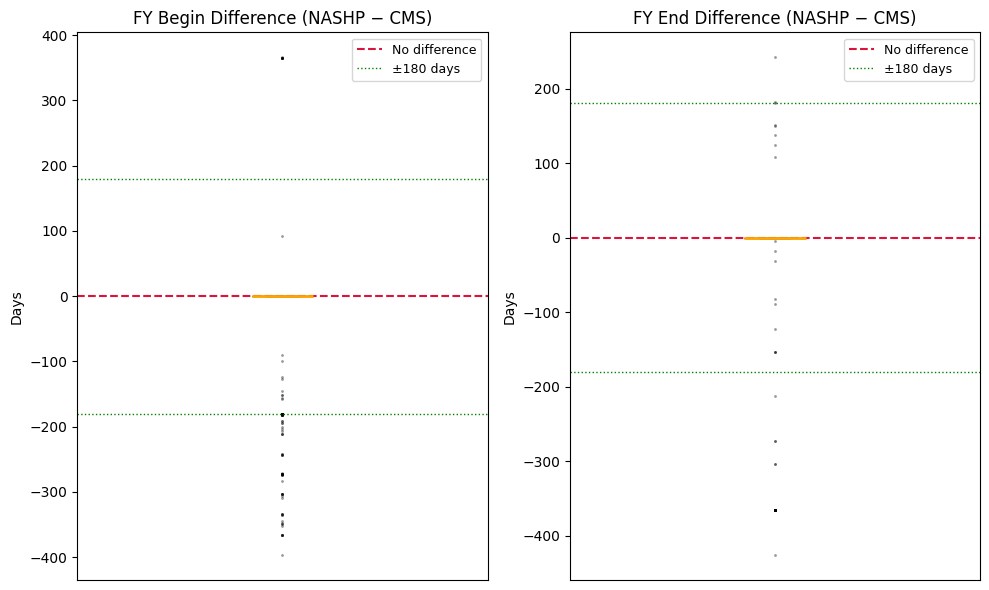

In [38]:
# ── CELL 10: CMS vs NASHP date difference visualization ───────────────────────
import matplotlib.pyplot as plt

out = pd.read_csv(OUTPUT_PATH, dtype=str, low_memory=False)

begin_diff = (
    pd.to_datetime(out["FY_Begin_NASHP"], errors="coerce") -
    pd.to_datetime(out["FY_Begin_CMS"],   errors="coerce")
).dt.days

end_diff = (
    pd.to_datetime(out["FY_End_NASHP"], errors="coerce") -
    pd.to_datetime(out["FY_End_CMS"],   errors="coerce")
).dt.days

def summarize(series, label):
    valid = series.dropna()
    n = len(valid)
    exact_n  = (valid == 0).sum()
    within_n = ((valid.abs() > 0) & (valid.abs() <= 180)).sum()
    beyond_n = (valid.abs() > 180).sum()
    print(f"{label}:")
    print(f"  {exact_n:,} rows exactly 0 days apart ({100*exact_n/n:.1f}%)")
    print(f"  {within_n:,} rows 1–180 days apart    ({100*within_n/n:.1f}%)")
    print(f"  {beyond_n:,} rows over 180 days apart  ({100*beyond_n/n:.1f}%)\n")

summarize(begin_diff, "FY Begin")
summarize(end_diff,   "FY End")

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

for ax, diff, label in zip(axes, [begin_diff, end_diff], ["FY Begin", "FY End"]):
    valid = diff.dropna()
    ax.boxplot(valid, vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", color="navy"),
               medianprops=dict(color="orange", linewidth=2),
               whiskerprops=dict(color="navy"),
               capprops=dict(color="navy"),
               flierprops=dict(marker=".", markersize=2, color="gray", alpha=0.4))
    ax.axhline(0,    color="crimson", linewidth=1.5, linestyle="--", label="No difference")
    ax.axhline(180,  color="green",   linewidth=1,   linestyle=":",  label="±180 days")
    ax.axhline(-180, color="green",   linewidth=1,   linestyle=":")
    ax.set_title(f"{label} Difference (NASHP − CMS)", fontsize=12)
    ax.set_ylabel("Days")
    ax.set_xticks([])
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()